In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
# CONFIGURACION GENERAL_ Solo para visualización; Esto afecta a todos los print de numpy que hagas después
np.set_printoptions(precision=3, suppress=True)#precision=3→3decimales;suppress=True→no usar notación científica

# Insight  
En el mundo de los datos, un Insight (o hallazgo) es el momento "¡Ajá!". No es solo ver un número, sino entender qué significa ese número para el negocio y qué acción debes tomar al respecto.

Dato: "Vendimos 500 unidades en la región Sur". (Es un hecho crudo).
Información: "Las ventas en el Sur cayeron un 20% respecto al mes pasado". (Es el dato con contexto).
Insight: "Las ventas en el Sur cayeron porque los precios subieron justo cuando la competencia lanzó una promoción; sin embargo, los clientes más fieles siguieron comprando". (Es la comprensión profunda).
Acción: "Debemos crear un programa de lealtad en el Sur para proteger a los clientes fieles antes de bajar los precios".

### FORMULA
Un insight es: hallazgo + evidencia + acción o hipótesis:  
hallazgo: Bogotá es la ciudad líder  
Evidencia: Aporta 42% de ventas  
Acción: Analizar qué hace bien Bogotá y replicarlo en otras ciudades  

In [8]:
# data_ejBorrable.csv
df = pd.read_csv("./data/data_ventas_de_servicios.csv")
df.head(20)

# empresa que vende servicios (Salud, Educación, Finanzas) y productos (Retail).
# Data registra quién compra (edad), dónde (ciudad) y por qué medio (Online, Tienda, Call Center).


,id_registro,fecha,ciudad,categoria,canal,edad,ventas
0,1001,2025-02-10,Bogotá,Salud,Online,34,1336.75
1,1002,2025-01-28,Bogotá,Retail,Tienda,40,2293.54
2,1003,2025-05-15,Cali,Salud,Tienda,16,209.96
3,1004,2025-03-13,Medellín,Salud,Call Center,20,1434.83
4,1006,2025-06-11,Bogotá,Educación,Tienda,19,2918.62
5,1007,2025-02-02,Medellín,Salud,Call Center,31,1391.24
6,1008,2025-02-17,Desconocido,Salud,Call Center,39,2367.42
7,1009,2025-05-31,Bogotá,Educación,Tienda,31,427.19
8,1010,2025-03-03,Bogotá,Salud,Online,17,4705.63
9,1011,2025-02-06,Desconocido,Salud,Online,40,2112.36


In [9]:
# cuantos null hay por columna
print(df.isnull().sum())

id_registro    0
fecha          0
ciudad         0
categoria      0
canal          0
edad           0
ventas         0
dtype: int64


In [10]:
# BORRABLE
# # Que porcentaje son los jóvenes que compran online vs. los adultos y adultos mayores?
# total_jovenes = preferencias_canal.loc['Jóvenes'].sum()
# total_adultos = preferencias_canal.loc['Adultos'].sum()
# total_adultos_mayores = preferencias_canal.loc['Adultos Mayores'].sum()
# # Porcentaje de personas que compran online, por call center y por tienda.
# total_online = preferencias_canal['Online'].sum()
# total_call_center = preferencias_canal['Call Center'].sum()
# total_tienda = preferencias_canal['Tienda'].sum()

# # deseo llegar a esto:
# # el canal menos usado es el Online


#### caso01

In [11]:
# Indagar sobre la POBLACION de usuario SEGMENTADOS y los canales usados por cada segmento.

# Definir rangos de edad
bins = [0, 35, 55, 100]
labels = ['Jóvenes', 'Adultos', 'Adultos Mayores']

# NUEVA COLUMNA DE SEGMENTO DE EDAD
df['Segmento Edad'] = pd.cut(df['edad'], bins=bins, labels=labels, right=False) # USO DE BINS
df.head(3)
# 	id_registro	fecha	ciudad	categoria	canal	edad	ventas	Segmento Edad
# 0	1001	2025-02-10	Bogotá	Salud	Online	34	1336.75	Jóvenes
# 1	1002	2025-01-28	Bogotá	Retail	Tienda	40	2293.54	Adultos
# 2	1003	2025-05-15	Cali	Salud	Tienda	16	209.96	Jóvene


,id_registro,fecha,ciudad,categoria,canal,edad,ventas,Segmento Edad
0,1001,2025-02-10,Bogotá,Salud,Online,34,1336.75,Jóvenes
1,1002,2025-01-28,Bogotá,Retail,Tienda,40,2293.54,Adultos
2,1003,2025-05-15,Cali,Salud,Tienda,16,209.96,Jóvenes


In [12]:
#### ANALISIS DE CANALES DE COMPRA ###########################

# Agrupar por segmento de edad y canal de compra, y contar las preferencias
preferencias_canal = df.groupby(['Segmento Edad', 'canal']).size().unstack(fill_value=0)
# porcentajes_canal = preferencias_canal.div(preferencias_canal.sum(axis=1), axis=0) * 100
print(" --- Preferencias de canal por segmento de edad: ----")
print(preferencias_canal)
# Preferencias de canal por segmento de edad:
# canal            Call Center  Online  Tienda
# Segmento Edad
# Jóvenes                   13       9      12
# Adultos                   26      16      20
# Adultos Mayores            7       3       8
print("___"*10)


# VALIDAR el canal menos usado en general #####################
# (sin importar el segmento de edad dado que en la tabla "preferencias_canal" se nota el menos usado por grupo y por tanto tambien lo sera en general).
# Calcular el total de ventas por cada canal (Suma de columnas)
ventas_por_canal = preferencias_canal.sum(axis=0)
# Identificar el canal menos usado
canal_menos_usado = ventas_por_canal.idxmin()
total_menos_usado = ventas_por_canal.min()
print(f" --- El canal menos usado es: '{canal_menos_usado}' con solo {total_menos_usado} transacciones.")
#El canal menos usado es: 'Online' con solo 28 transacciones.
print("VS")
print(f" --- El canal más usado es: '{ventas_por_canal.idxmax()}' con {ventas_por_canal.max()} transacciones.")
# El canal más usado es: 'Call Center' con 46 transacciones.
print("___"*10)
# VALIDAR que 'ciudad' compra mas 'Online' y quen mas en 'Call Center'  #####################
# ONLINE
ventas_online_por_ciudad = df[df['canal'] == 'Online'].groupby('ciudad').size()
ciudad_mas_online = ventas_online_por_ciudad.idxmax()
total_mas_online = ventas_online_por_ciudad.max()
print(f">>La ciudad que más compra Online es: '{ciudad_mas_online}' con {total_mas_online} transacciones.")
#La ciudad que más compra Online es: 'Medellín' con 8 transacciones.
# LISTAR TODAS LAS CIUDADES CON SUS VENTAS ONLINE
print("\nVentas Online por ciudad (LISTA):")
print(ventas_online_por_ciudad.sort_values(ascending=False).head(5))
# ciudad
# Medellín        8
# Bogotá          7
# Cali            5
# Barranquilla    4
# Cartagena       2
print(" - - - - - -"*5)
# CALL CENTER
ventas_call_center_por_ciudad = df[df['canal'] == 'Call Center'].groupby('ciudad').size()
ciudad_mas_call_center = ventas_call_center_por_ciudad.idxmax()
total_mas_call_center = ventas_call_center_por_ciudad.max()
print(f">> La ciudad que más compra por Call Center es: '{ciudad_mas_call_center}' con {total_mas_call_center} transacciones.")
# La ciudad que más compra por Call Center es: 'Bogotá' con 12 transacciones.
# LISTAR TODAS LAS CIUDADES CON SUS VENTAS ONLINE
print("\nVentas Call Center por ciudad (LISTA):")
print(ventas_call_center_por_ciudad.sort_values(ascending=False).head(5))
# Ventas Call Center por ciudad (LISTA):
# ciudad
# Bogotá          12
# Medellín         9
# Barranquilla     7
# Cali             6
# Cartagena        6
print("___"*10)



# Insight 1: Paradoja Digital
# Hallazgo: El canal Online es el menos efectivo de la compañía, incluso entre los jovenes.
# Evidencia: Con solo 28 transacciones, el canal Online es superado por el Call Center (46 transacciones),
  # Lo más crítico es que en el segmento "Jóvenes", el Call Center (13) también supera al Online (9).
# Acción: Realizar una encuesta de satisfacción a los clientes del segmento "Jóvenes" que compraron por Call Center para entender qué barreras encontraron en la web
  # (¿confianza, métodos de pago, o complejidad?).






 --- Preferencias de canal por segmento de edad: ----
canal            Call Center  Online  Tienda
Segmento Edad                               
Jóvenes                   13       9      12
Adultos                   26      16      20
Adultos Mayores            7       3       8
______________________________
 --- El canal menos usado es: 'Online' con solo 28 transacciones.
VS
 --- El canal más usado es: 'Call Center' con 46 transacciones.
______________________________
>>La ciudad que más compra Online es: 'Medellín' con 8 transacciones.

Ventas Online por ciudad (LISTA):
ciudad
Medellín        8
Bogotá          7
Cali            5
Barranquilla    4
Cartagena       2
dtype: int64
 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
>> La ciudad que más compra por Call Center es: 'Bogotá' con 12 transacciones.

Ventas Call Center por ciudad (LISTA):
ciudad
Bogotá          12
Medellín         9
Barranquilla     7
Cali             6
Cartagena        6
dtype: int64
________________

<Figure size 1000x600 with 0 Axes>

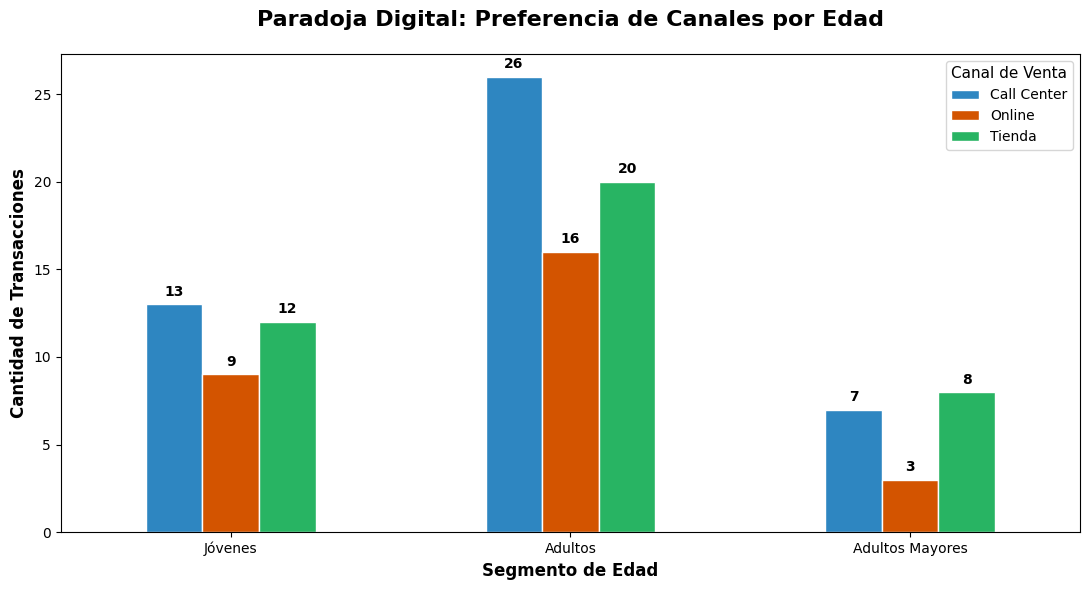

In [13]:
# import matplotlib.pyplot as plt

# 1. Configurar el estilo y tamaño
plt.figure(figsize=(10, 6))

# 2. Graficar la tabla preferencias_canal
# Usamos un set de colores profesional (Paleta 'coolwarm' o personalizada)
ax = preferencias_canal.plot(kind='bar',
                             figsize=(11, 6),
                             color=['#2E86C1', '#D35400', '#28B463'], # Azul, Naranja, Verde
                             edgecolor='white')

# 3. Personalizar Títulos y Etiquetas
plt.title('Paradoja Digital: Preferencia de Canales por Edad', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Segmento de Edad', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Transacciones', fontsize=12, fontweight='bold')
plt.xticks(rotation=0) # Para que "Jóvenes", "Adultos", etc., se lean horizontal

# 4. Agregar Leyenda
plt.legend(title='Canal de Venta', title_fontsize='11', loc='upper right')

# 5. Agregar Etiquetas de Datos (Los números sobre las barras)
# Esto es clave para la "Evidencia"
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

# 6. Ajustar diseño para que no se corte nada
plt.tight_layout()

# 7. Mostrar gráfico
plt.show()

### Insight 1: Paradoja Digital  
**Hallazgo: El canal Online es el menos efectivo de la compañía, incluso entre los jovenes.**  
- Evidencia: Con solo 28 transacciones, el canal Online es superado por el Call Center (46 transacciones), Lo más crítico es que en el segmento "Jóvenes", el Call Center (13) también supera al Online (9).  
- Acción: Realizar una encuesta de satisfacción a los clientes del segmento "Jóvenes" que compraron por Call Center para entender qué barreras encontraron en la web (¿confianza, métodos de pago, o complejidad?).  


#### caso02

In [14]:
# LISTAR, POR SEGMENTO DE 'edad', y asu ves POR 'categoria' y por venta total de la categoria.
ventas_por_segmento_categoria = df.groupby(['Segmento Edad', 'categoria'])['ventas'].sum().unstack(fill_value=0)
print("\nVentas totales por segmento de edad y categoría:")
print(ventas_por_segmento_categoria)


Ventas totales por segmento de edad y categoría:
categoria        Educación  Finanzas    Retail     Salud
Segmento Edad                                           
Jóvenes           16549.93  16046.04  18534.22  18801.93
Adultos           55210.48  17372.80  45652.61  39235.00
Adultos Mayores   18699.11   1200.50   9883.96  15626.92


In [15]:
# LISTAR, POR SEGMENTO DE 'edad', y asu ves POR CANAL, y su vez 'categoria' y por venta total de la categoria.

# ventas_por_segmento_canal_categoria = df.groupby(['Segmento Edad', 'canal', 'categoria'])['ventas'].sum()
ventas_por_segmento_canal_categoria = df.groupby(['Segmento Edad', 'canal', 'categoria'])['ventas'].sum().unstack(fill_value=0)
print("\nVentas totales por segmento de edad, canal y categoría:")
print(ventas_por_segmento_canal_categoria)



Ventas totales por segmento de edad, canal y categoría:
categoria                    Educación  Finanzas    Retail     Salud
Segmento Edad   canal                                               
Jóvenes         Call Center    7488.79   4067.41   6482.91  12126.56
                Online          687.30   7462.79   1294.64   6465.41
                Tienda         8373.84   4515.84  10756.67    209.96
Adultos         Call Center   21526.11  17372.80   9814.95  18238.85
                Online        16776.13      0.00   4737.30  15918.41
                Tienda        16908.24      0.00  31100.36   5077.74
Adultos Mayores Call Center    6656.29   1200.50   9883.96      0.00
                Online         7036.48      0.00      0.00   2407.24
                Tienda         5006.34      0.00      0.00  13219.68
